# 直方图和模板匹配
- 直方图
- 直方图均衡化
- 模板匹配

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

## 直方图
OpenCV 中的直方图的主要功能是可以查看图像的像素信息<br/>
以及提取直方图中各个区间的像素值的数目，作为当前图像的特征属性进行机器学习

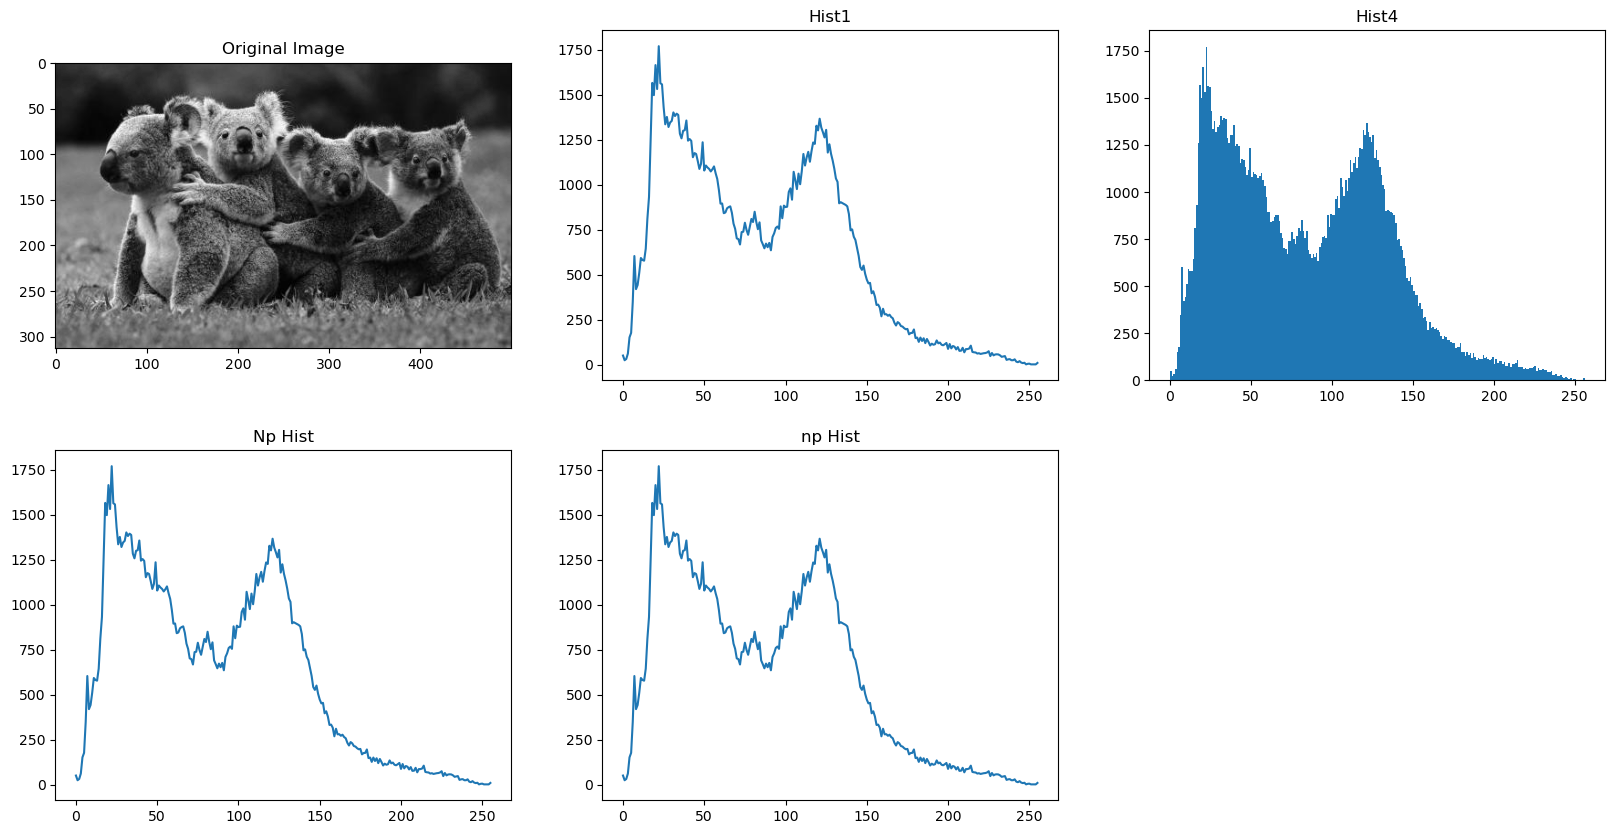

In [2]:
# 加载灰度图
img = cv.imread('./images/koala.png', 0)

# 两种方式结果类似
# 1.基于 OpenCV 的 API 计算直方图
# channels=[0]：指定要计算直方图的通道索引（灰度图只有 1 个通道）
# mask=None：不使用掩膜
# histSize=[256]：将灰度级分成 256 个柱子（bin），每个柱子对应一个灰度值，范围 0-255
# ranges=[0, 256]：统计灰度值从 0 到 255（256 是上限，不包含）
# hist1：直方图数据，是一个形状为(256, 1)的二维数组，每个元素对应一个灰度级的像素数量
hist1 = cv.calcHist([img], channels=[0], mask=None, histSize=[256], ranges=[0, 256])

# 2.基于 NumPy 计算直方图
# img.ravel()：输入图像的一维扁平化
# 256：直方图的柱子数量
# [0, 256]：统计的像素值范围
# hist2：直方图数据，是一个长度为 256 的一维数组，每个元素表示对应灰度级的像素数量
hist2, bins = np.histogram(img.ravel(), 256, [0, 256])

# 和 np.histogram 一样的计算方式，但是效率快 10 倍
hist3 = np.bincount(img.ravel(), minlength=256)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(231)
plt.imshow(img, 'gray')
plt.title('Original Image')

plt.subplot(232)
plt.plot(hist1)  # cv.calcHist
plt.title('Hist1')

plt.subplot(233)
# 可以直接使用 matpliab 中的 hist API 直接画直方图
plt.hist(img.ravel(), 256, [0, 256])  
plt.title('Hist4')

plt.subplot(234)
plt.plot(hist2)  # np.histogram
plt.title('Np Hist')

plt.subplot(235)
plt.plot(hist3)  # np.bincount
plt.title('np Hist')

plt.show()

In [3]:
print(hist3.shape)
hist3

(256,)


array([  51,   25,   32,   62,  152,  177,  349,  604,  420,  443,  511,
        593,  582,  578,  645,  811,  932, 1258, 1566, 1498, 1665, 1532,
       1770, 1564, 1558, 1431, 1336, 1377, 1321, 1346, 1355, 1402, 1382,
       1395, 1388, 1284, 1258, 1300, 1303, 1357, 1245, 1254, 1244, 1153,
       1176, 1171, 1132, 1088, 1116, 1236, 1079, 1107, 1096, 1088, 1074,
       1086, 1102, 1064, 1032,  971,  895,  896,  842,  846,  869,  876,
        880,  844,  784,  755,  702,  698,  668,  737,  739,  789,  749,
        722,  767,  810,  793,  850,  794,  753,  791,  691,  670,  647,
        673,  653,  677,  636,  710,  730,  760,  768,  755,  880,  814,
        884,  876,  878,  960,  980,  917, 1072, 1026,  976, 1062, 1003,
       1075, 1171, 1107, 1152, 1183, 1128, 1187, 1235, 1227, 1328, 1302,
       1367, 1318, 1292, 1263, 1305, 1179, 1225, 1172, 1135, 1090, 1035,
       1016,  897,  903,  898,  893,  888,  880,  837,  747,  752,  711,
        693,  650,  605,  543,  527,  551,  505,  4

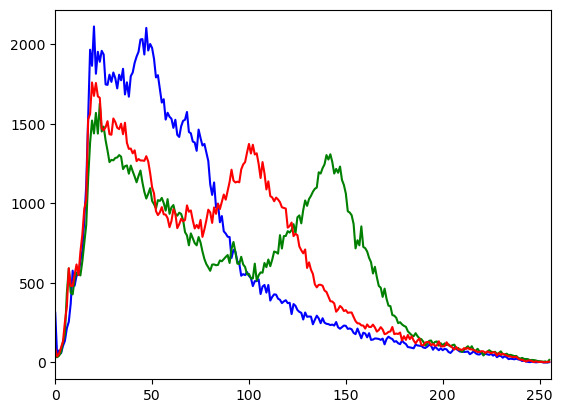

In [4]:
# 针对彩色图像计算直方图
img = cv.imread('./images/koala.png')

# 蓝色、绿色、红色
color = ['b', 'g', 'r']

# 遍历颜色通道并计算直方图
for i, col in enumerate(color):
    # 计算直方图
    histr = cv.calcHist([img], channels=[i], mask=None, histSize=[256], ranges=[0, 256])
    # 绘制直方图
    plt.plot(histr, color=col)
    # 设置 x 轴范围
    plt.xlim([0, 256])       
plt.show()

直方图的形状： (255, 1)


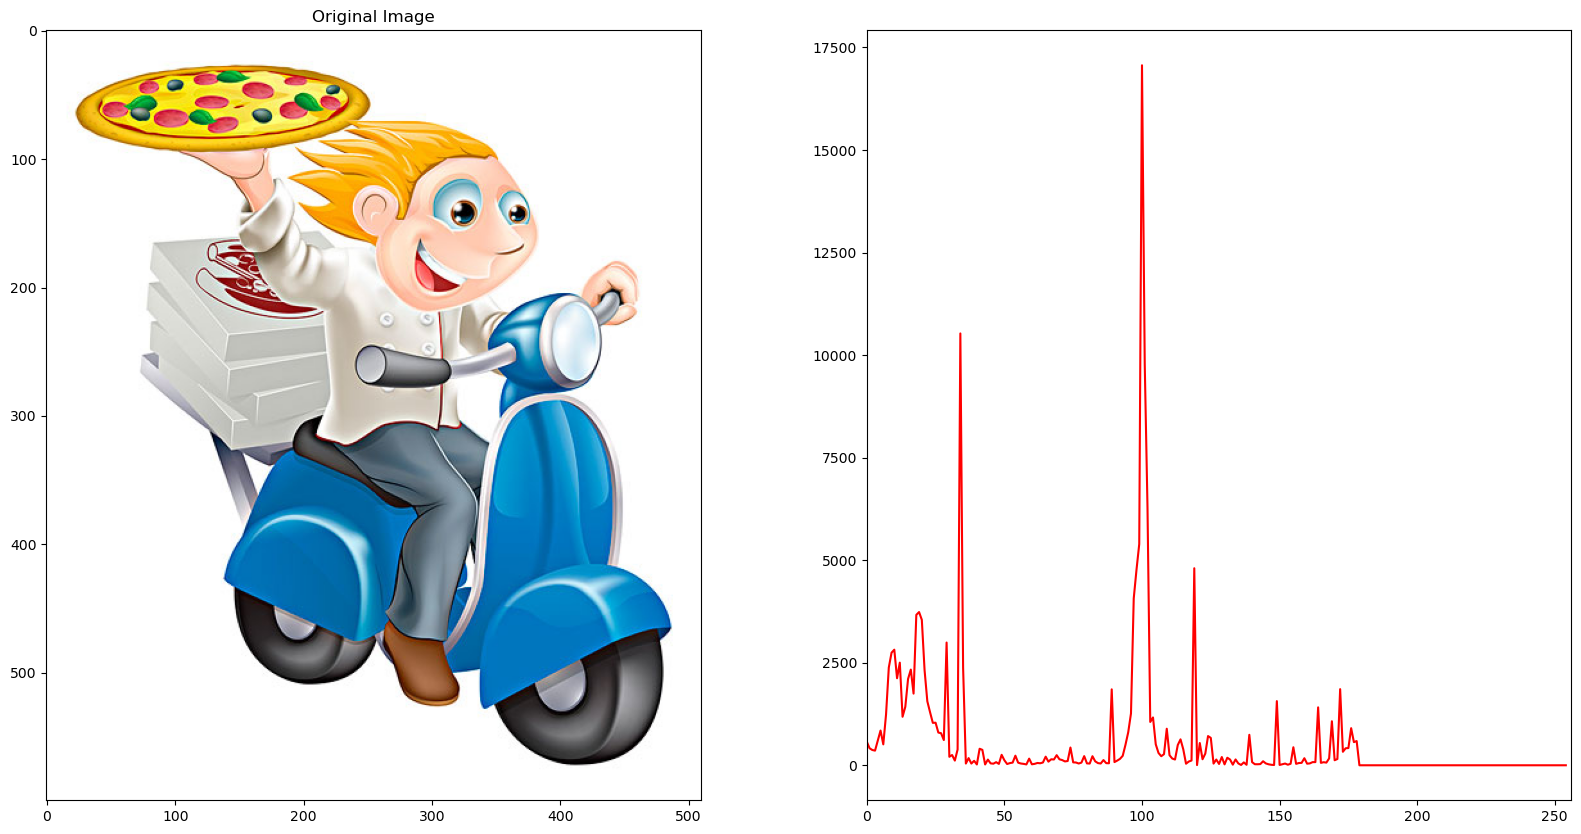

In [5]:
"""单独针对 H 通道（色调）进行统计计算"""

# img = cv.imread ('./images/koala.png')
img = cv.imread('./images/xiaoren.png')
# img = cv.imread('./images/gray2.png')  # histr[0] = [29493.]，大面积的无效色调（H=0）

# 从 BGR 转换为 HSV （色调-饱和度-明度）
hsv_img = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# H 通道的直方图
# channels=[0]：色调通道 [0, 179]
# [1:, :]：去掉直方图的第一个 bin，以忽略大面积的无效色调（H=0）
# 无效色调：饱和度为 0 的颜色，例如黑色、白色或灰色，此时 H 值无意义（通常被设为 0）
histr = cv.calcHist([hsv_img], channels=[0], mask=None, histSize=[256], ranges=[0, 256])[1:, :]
print("直方图的形状：", histr.shape)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.title('Original Image')

plt.subplot(122)
plt.plot(histr, color='red')  # 直方图
plt.xlim([0, 256])
plt.show()


直方图的形状： (254, 1)

直方图的形状： (254, 1)

直方图的形状： (254, 1)


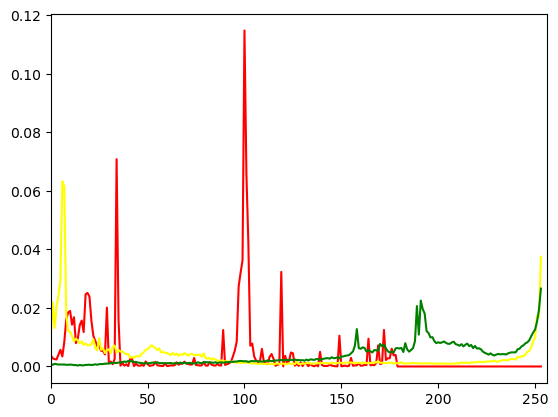

In [6]:
"""针对 HSV 图像计算直方图"""

# 加载图像
# img = cv.imread('./images/koala.png')
img = cv.imread('./images/xiaoren.png')

# 从 BGR 转换为 HSV （色调-饱和度-明度）
img = cv.cvtColor(img, cv.COLOR_BGR2HSV)  

# H -> 红色，S -> 黄色，V -> 绿色
color = ('red', 'yellow', 'green')
for i, col in enumerate(color):
    # 计算直方图
    # if i > 0:  # 只计算色调直方图
    #     continue
    # channels=[0]：色调通道 [0, 179]
    # channels=[1]：饱和度 [0, 255]
    # channels=[2]：明度 [0, 255]
    # [1:255, :]：去掉前后 2 个极端值
    # 1.去掉直方图的第 1 个 bin，以忽略无效色调（H=0）（因面积比较大，导致数值比较大）
    #   无效色调：饱和度为 0 的颜色，例如黑色、白色或灰色，此时 H 值无意义（通常设为 0）
    # 2.去掉直方图的最后 1 个 bin，以忽略白色明度（V=255）（因面积比较大，导致数值比较大）
    histr = cv.calcHist([img], channels=[i], mask=None, histSize=[256], ranges=[0, 256])[1:255, :]
    # 归一化直方图（消除数量级影响）
    histr = histr / np.sum(histr)
    # print("\n归一化后的直方图：\n", histr[:5], sep="")
    print("\n直方图的形状：", histr.shape)
    
    # 绘制直方图
    plt.plot(histr, color=col)
    plt.xlim([0, 256])
plt.show()

直方图的形状： (255, 1)


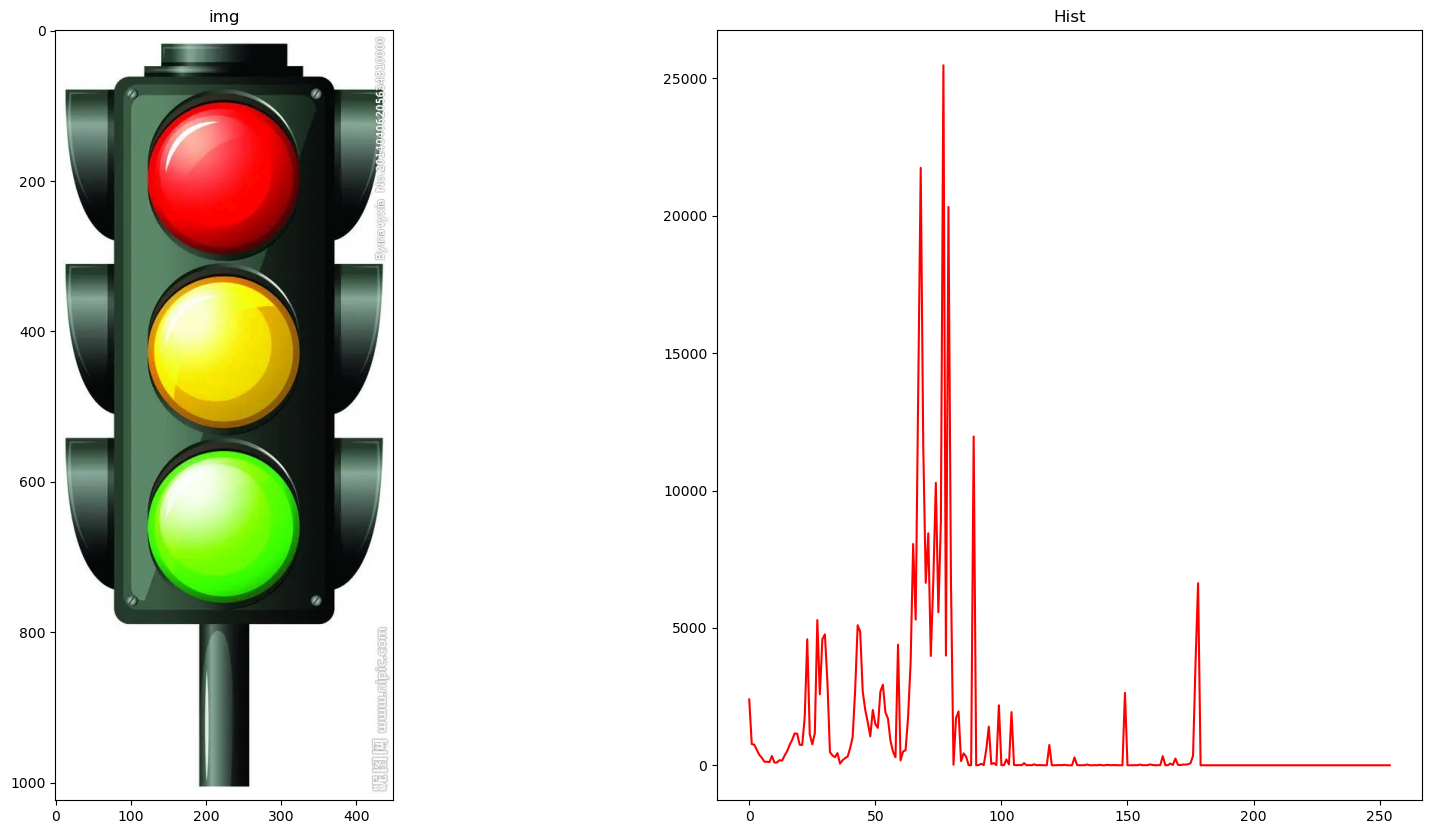

In [7]:
"""针对 HSV 图像计算直方图"""

# 加载图像
img = cv.imread("./images/t.png")
# 转为 HSV 格式
img = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# channels=[0]：对色调通道进行统计
chistr = cv.calcHist([img], channels=[0], mask=None, histSize=[256], ranges=[0, 256])[1:, :]
print("直方图的形状：", chistr.shape)

# 可视化
plt.figure(figsize=(20, 10))
plt.subplot(121)
plt.imshow(cv.cvtColor(img, cv.COLOR_HSV2RGB))
plt.title('img')

plt.subplot(122)
plt.plot(chistr, color='red')  # 直方图
plt.title('Hist')

plt.show()

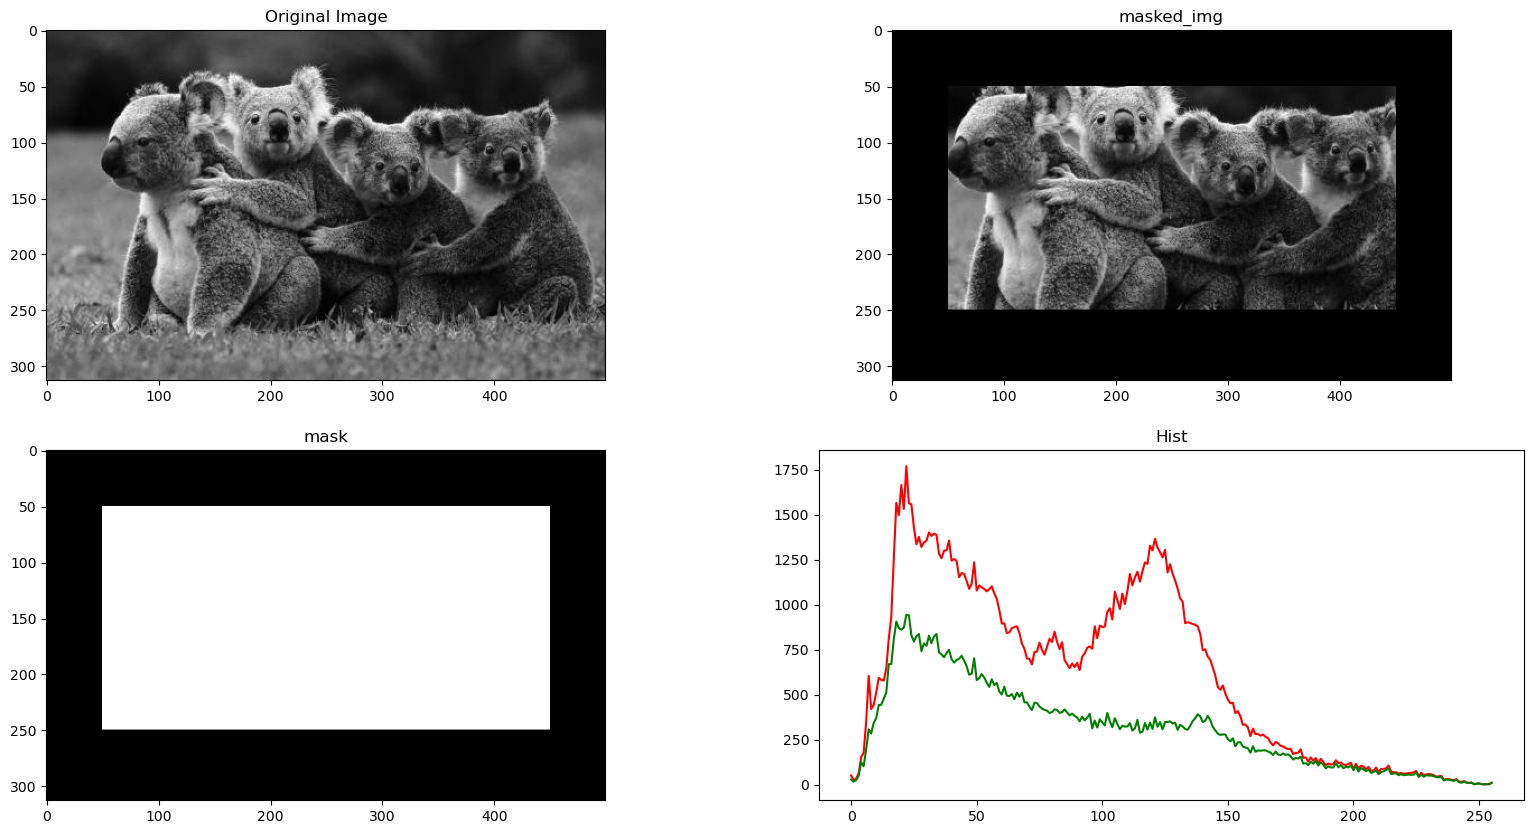

In [8]:
"""加入 mask 位置信息的直方图"""

# 加载灰度图
img = cv.imread('./images/koala.png', 0)

# 创建一个 mask
# 填充黑色，为屏蔽区域
mask = np.zeros(img.shape[:2], np.uint8)
# 中间填充白色，为保留区域
mask[50:250, 50:450] = 255

# 构建 mask 区域的图像
# 当 mask 值为 255 时，对应位置的像素进行按位与运算
masked_img = cv.bitwise_and(img, img, mask=mask)

# 计算直方图
# channels=[0]：指定要计算直方图的通道索引（灰度图只有 1 个通道）
hist1 = cv.calcHist([img], channels=[0], mask=None, histSize=[256], ranges=[0, 256])         # 不带掩膜
hist2 = cv.calcHist([masked_img], channels=[0], mask=mask, histSize=[256], ranges=[0, 256])  # 带掩膜

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(221)
plt.imshow(img, 'gray')
plt.title('Original Image')

plt.subplot(222)
plt.imshow(masked_img, 'gray')  # 带 mask 的图像
plt.title('masked_img')

plt.subplot(223)
plt.imshow(mask, 'gray')        # mask 图
plt.title('mask')

plt.subplot(224)
plt.plot(hist1, color='red')    # 整个图像的 -> 每个颜色值数量较多
plt.plot(hist2, color='green')  # 仅计算 mask 区域的 -> 每个颜色值数量较少
plt.title('Hist')

plt.show()

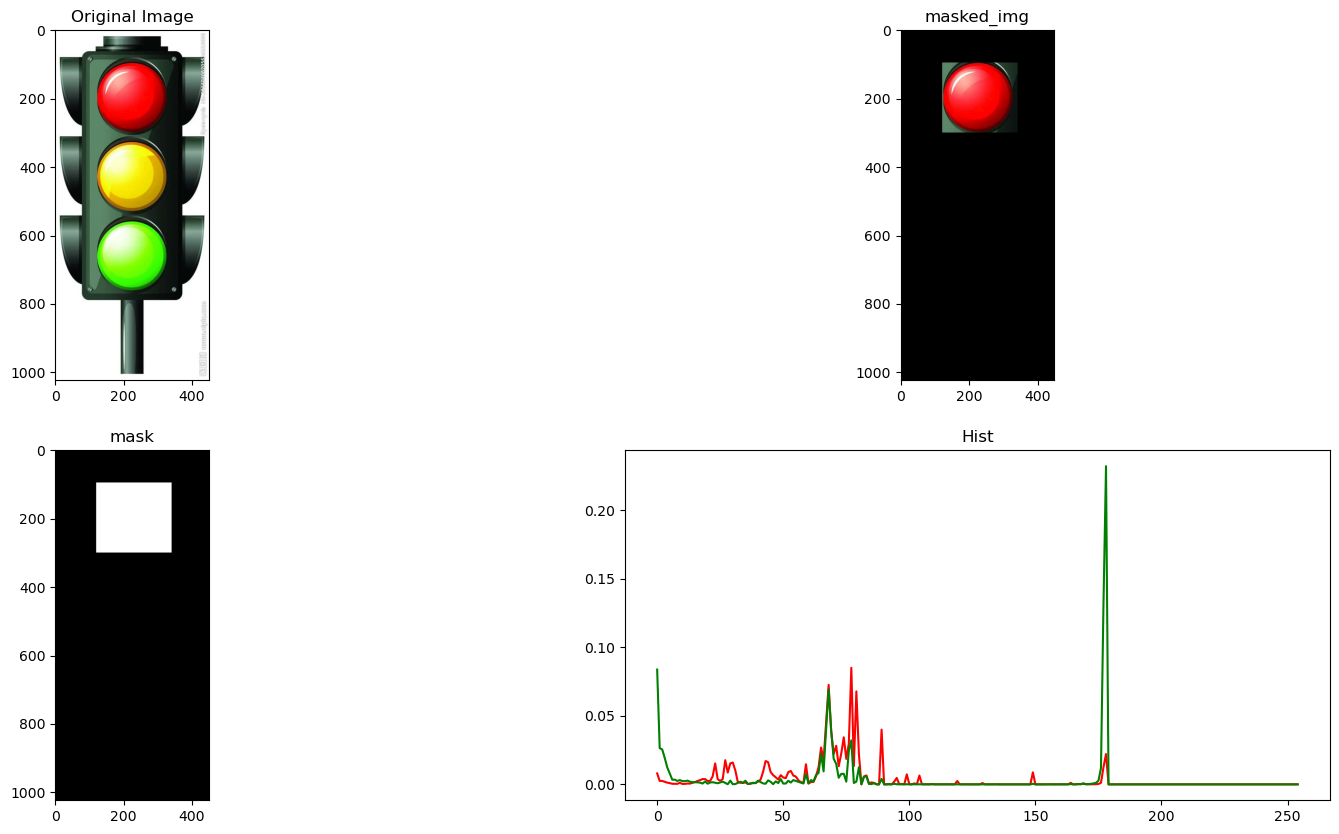

In [9]:
"""加入 mask 位置信息的直方图"""

# 加载图像
img = cv.imread('./images/t.png')
# 转为 HSV 格式
img = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# 创建一个 mask
# 填充黑色，为屏蔽区域
mask = np.zeros(img.shape[:2], np.uint8)  
mask[95:300, 120:340] = 255  # 红灯
# mask[320:530, 120:340] = 255  # 黄灯
# mask[550:770, 120:340] = 255  # 绿灯

# 构建 mask 区域的图像
masked_img = cv.bitwise_and(img, img, mask=mask)

# 计算直方图
hist1 = cv.calcHist([img], channels=[0], mask=None, histSize=[256], ranges=[0, 256])[1:, :]        # 不带掩膜
hist1 = hist1 / np.sum(hist1)  # 归一化
hist2 = cv.calcHist([masked_img], channels=[0], mask=mask, histSize=[256], ranges=[0,256])[1:, :]  # 带掩膜
hist2 = hist2 / np.sum(hist2)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(221)
plt.imshow(cv.cvtColor(img, cv.COLOR_HSV2RGB))
plt.title('Original Image')

plt.subplot(222)
plt.imshow(cv.cvtColor(masked_img, cv.COLOR_HSV2RGB))  # 带 mask 的图像
plt.title('masked_img')

plt.subplot(223)
plt.imshow(mask, 'gray')        # mask 图
plt.title('mask')

plt.subplot(224)
plt.plot(hist1, color='red')    # 整个图像的 -> 绿色最多
plt.plot(hist2, color='green')  # 仅计算 mask 区域的 -> 暴露的灯的颜色最多
plt.title('Hist')

plt.show()

图像形状： (1024, 449, 3)
掩膜形状： (1024, 449)


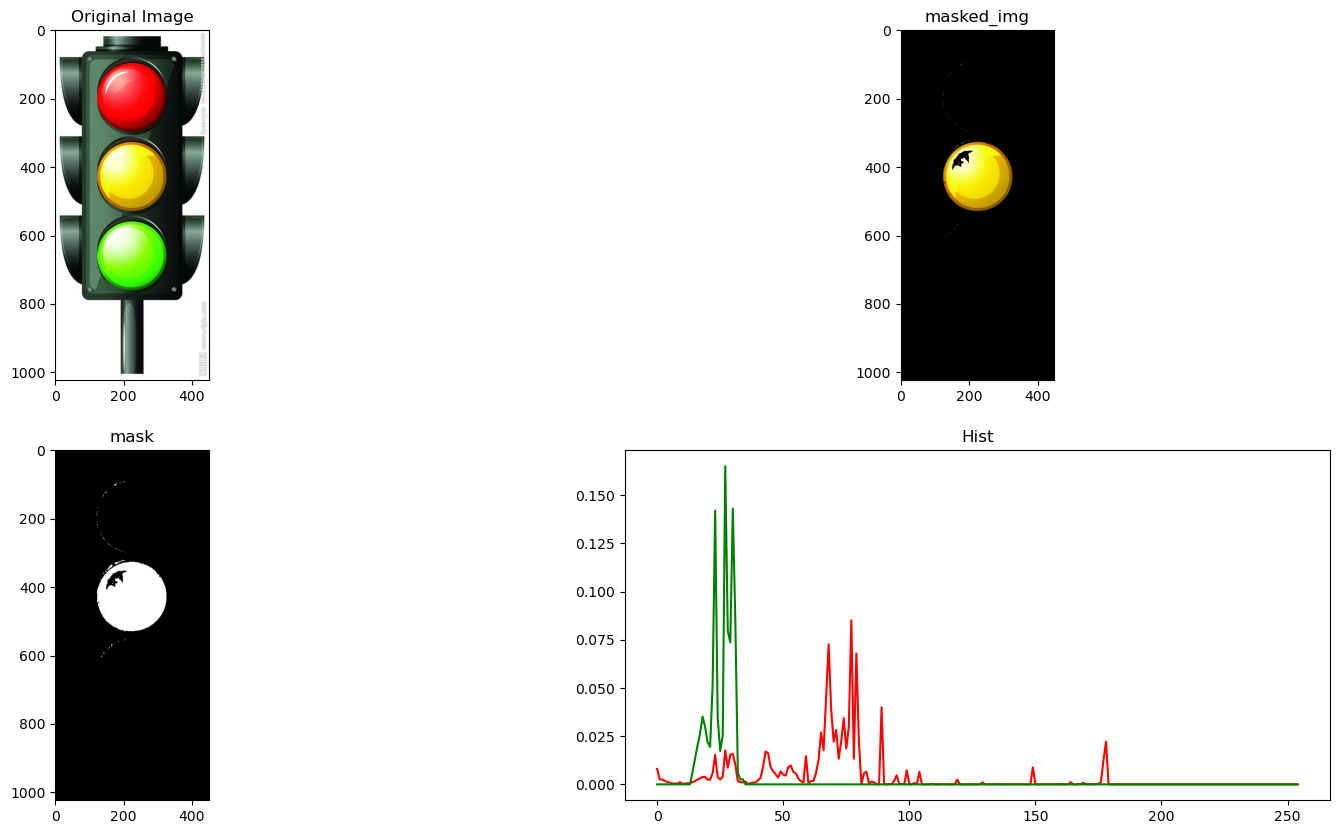

In [10]:
"""加入 mask 位置信息的直方图"""

# 加载图像
img = cv.imread('./images/t.png')
# 转为 HSV 格式
img = cv.cvtColor(img, cv.COLOR_BGR2HSV)

# 黄色的范围
lower = np.array([15, 50, 50])
upper = np.array([35, 255, 255])

# 绿色的范围
# lower = np.array([40, 50, 50])
# upper = np.array([60, 255, 255])

# 在某个颜色范围内的掩膜
mask = cv.inRange(img, lower, upper)
print("图像形状：", img.shape)
print("掩膜形状：", mask.shape)

# 构建 mask 区域的图像
masked_img = cv.bitwise_and(img, img, mask=mask)

# 计算直方图
hist1 = cv.calcHist([img], channels=[0], mask=None, histSize=[256], ranges=[0, 256])[1:, :]        # 不带掩膜
hist1 = hist1 / np.sum(hist1)  # 归一化
hist2 = cv.calcHist([masked_img], channels=[0], mask=mask, histSize=[256], ranges=[0,256])[1:, :]  # 带掩膜
hist2 = hist2 / np.sum(hist2)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(221)
plt.imshow(cv.cvtColor(img, cv.COLOR_HSV2RGB))
plt.title('Original Image')

plt.subplot(222)
plt.imshow(cv.cvtColor(masked_img, cv.COLOR_HSV2RGB))  # 带 mask 的图像
plt.title('masked_img')

plt.subplot(223)
plt.imshow(mask, 'gray')        # mask 图
plt.title('mask')

plt.subplot(224)
plt.plot(hist1, color='red')    # 整个图像的 -> 绿色最多
plt.plot(hist2, color='green')  # 仅计算 mask 区域的 -> 暴露的灯的颜色最多
plt.title('Hist')

plt.show()

## 直方图均衡化
如果某一个图像的像素仅限制于某个特定的范围，但是实际上一个比较好的图像像素点应该是在某一个范围内，所以需要将像素的直方图做一个拉伸的操作；<br>
比如：一个偏暗的图像，像素基本上都在较小的位置，如果将像素值增大，不就可以让图像变亮嘛！

实际上，直方图均衡化操作是一个提高图像对比度的方式。

![avatar](./images/histogram_equalization.png)

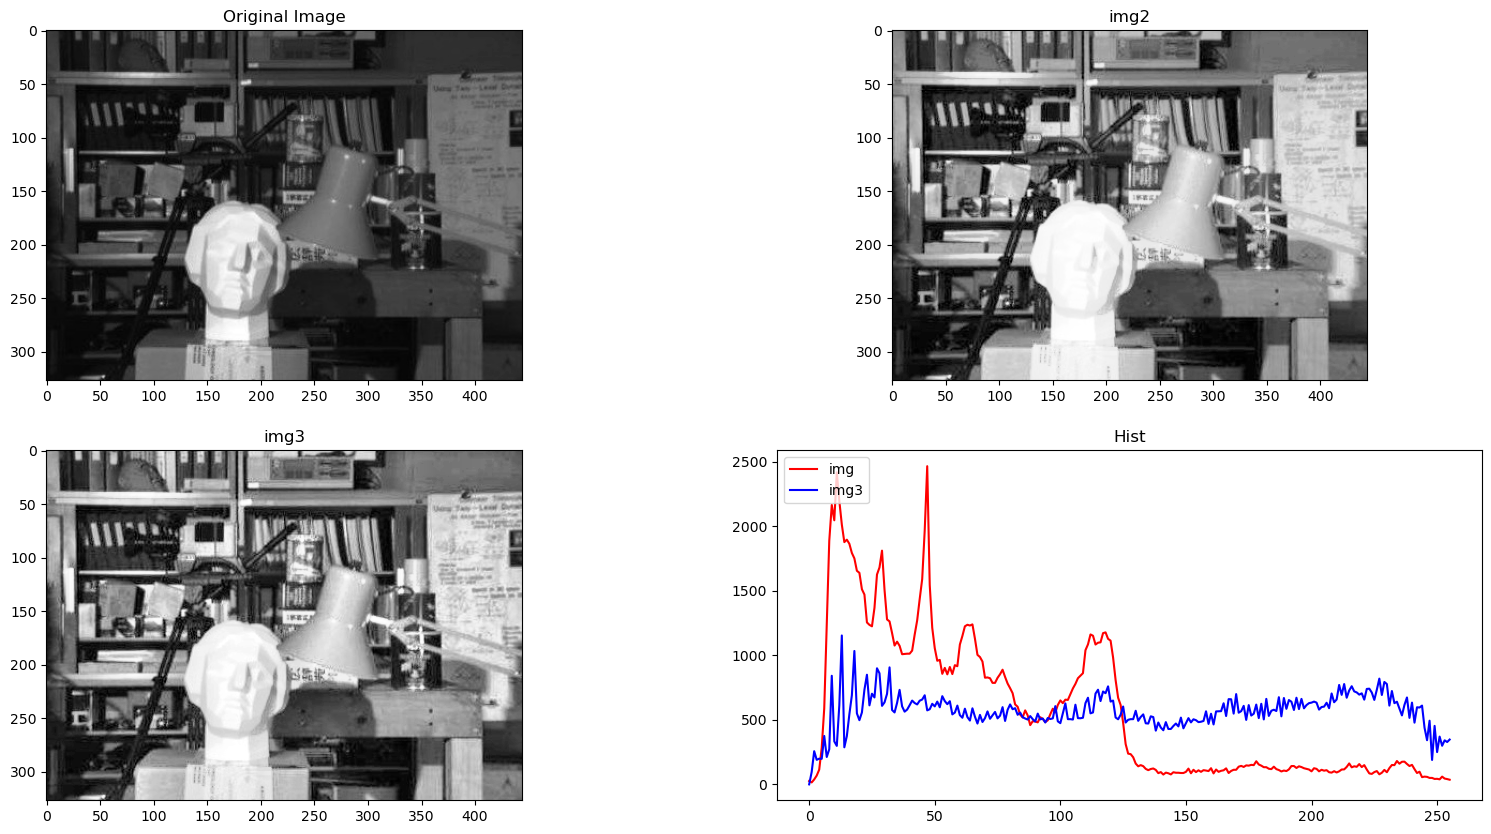

In [11]:
"""直方图均衡化"""

# 加载灰度图
img = cv.imread('./images/tsukuba.png', 0)
# img = cv.GaussianBlur(img, (5, 5), 0)

# 直方图均衡：增强图像的对比度
# 通过重新分布图像的灰度级，使得像素值均匀分布在所有可能的范围内（0~255）
# 从而让暗的区域更亮、亮的区域更暗，使图像细节更清晰
img2 = cv.equalizeHist(img)

# 自适应的直方图均衡（推荐）
# 用于增强图像的局部对比度，同时避免传统直方图均衡化可能带来的过度增强问题
# clipLimit=2.0：值越小，对比度增强越温和；值越大，对比度越强，但可能放大噪声
# tileGridSize=(8, 8)：分块越小，局部对比度增强越细致，但计算量增大；分块越大，接近全局均衡化效果
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))  # 创建实例
# 执行自适应的直方图均衡
img3 = clahe.apply(img2)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(221)
plt.imshow(img, 'gray')
plt.title('Original Image')

plt.subplot(222)
plt.imshow(img2, 'gray')  # 直方图均衡
plt.title('img2')

plt.subplot(223)
plt.imshow(img3, 'gray')  # 自适应的直方图均衡
plt.title('img3')

plt.subplot(224)
plt.plot(cv.calcHist([img], [0], None, [256], [0, 256]), color='red', label='img')
# plt.plot(cv.calcHist([img2], [0], None, [256], [0, 256]), color='green', label='img2')  # 非自适应的直方图均衡不太好
plt.plot(cv.calcHist([img3], [0], None, [256], [0, 256]), color='blue', label='img3')
plt.legend(loc = 'upper left')
plt.title('Hist')

plt.show()

## 模板匹配
就是基于模板在原始图像中查找最匹配的位置

序号	 匹配方式	 左上角的点和右下角的点	 相似度
1	cv.TM_CCOEFF	((383, 499), (447, 558))	7951555.0
2	cv.TM_CCOEFF_NORMED	((383, 499), (447, 558))	0.9974133372306824
3	cv.TM_CCORR	((415, 472), (479, 531))	26082732.0
4	cv.TM_CCORR_NORMED	((383, 499), (447, 558))	0.9995109438896179
5	cv.TM_SQDIFF	((383, 499), (447, 558))	43296.0
6	cv.TM_SQDIFF_NORMED	((383, 499), (447, 558))	0.0010212447959929705


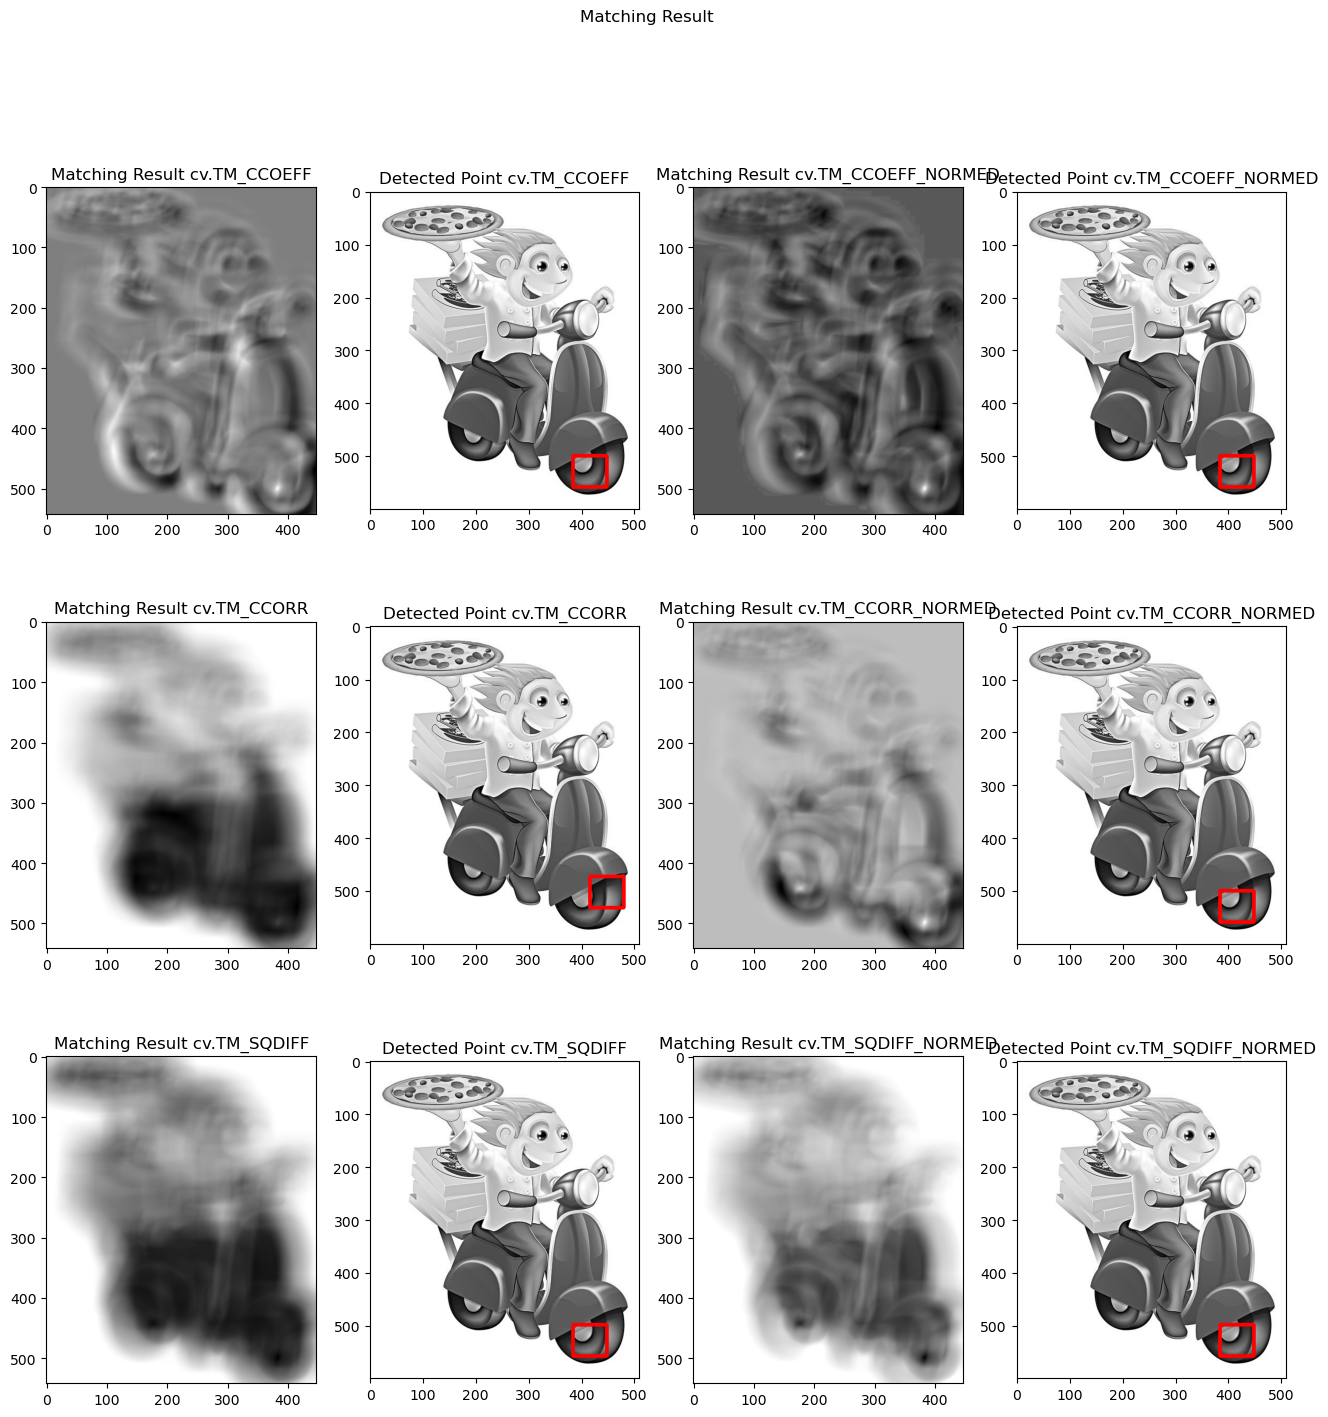

In [12]:
plt.figure(figsize=(16, 16))

# 加载灰度图
img = cv.imread('./images/xiaoren.png', cv.IMREAD_GRAYSCALE)  # 形状：(600, 510)
# img = cv.imread('./images/car.jpg', cv.IMREAD_GRAYSCALE)
# img = cv.imread('./images/plat_car.jpg', cv.IMREAD_GRAYSCALE)

# 拷贝图像
img2 = np.copy(img)

# 加载模板图像
template = cv.imread('./images/template.png', cv.IMREAD_GRAYSCALE)  # 形状：(59, 64)
# template = cv.imread('./images/plat_car_template.jpg', cv.IMREAD_GRAYSCALE)
# template = cv.imread('./images/car_plat_8.jpg', cv.IMREAD_GRAYSCALE)
# template = cv.resize(template, (32, 60))

# 得到模板图像的高度和宽度
h, w = template.shape

# 6种匹配方式
methods = [
    'cv.TM_CCOEFF',         # 相关系数匹配法
    'cv.TM_CCOEFF_NORMED',  # 归一化相关系数匹配法
    'cv.TM_CCORR',          # 相关匹配法
    'cv.TM_CCORR_NORMED',   # 归一化相关匹配法
    'cv.TM_SQDIFF',         # 平方差匹配法
    'cv.TM_SQDIFF_NORMED'   # 归一化平方差匹配法
]

print("序号\t", "匹配方式\t", "左上角的点和右下角的点\t", "相似度")

# img2 = img2[:, :400]
# 遍历
for idx, meth in enumerate(methods):
    # 拷贝图像
    img = np.copy(img2)
    
    # 得到对应的方式（eval的意思是执行）
    method = eval(meth)  # method = cv.TM_CCOEFF
    
    # 使用给定的方式进行模板匹配（返回值为各个局部区域和模板 template 之间的相似度）
    res = cv.matchTemplate(img, template, method)
    # print(res.shape)  # (542, 447)
    # print(res)
    """
    [[ 2.6811028e+05  2.4245320e+05  2.1970947e+05 ... -1.3000000e+01
      -5.0000000e+00 -5.0000000e+00]
     [ 2.6407000e+05  2.4055147e+05  2.2018261e+05 ...  3.0000000e+00
       3.0000000e+00  3.0000000e+00]
     ...
     [ 3.0000000e+00  3.0000000e+00  3.0000000e+00 ... -3.8438708e+06
      -3.6351588e+06 -3.4279178e+06]]
    """

    # 从数据中查找全局最小值、最大值，以及对应的位置
    min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
    
    # 如果求解方式为 cv.TM_CCORR、TM_SQDIFF 或 TM_SQDIFF_NORMED，
    # 那么矩形左上角的点就是最小值的位置；
    # 否则是最大值的位置
    if method in [cv.TM_CCORR, cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
        top_left = min_loc
    else:
        top_left = max_loc
    
    # 基于左上角的坐标计算右下角的坐标
    # 分别加上模板图像的宽度和高度
    bottom_right = (top_left[0] + w, top_left[1] + h)

    # 打印：序号、匹配方式、左上角的点和右下角的点、相似度
    print(f"{idx + 1}\t{meth}\t{(top_left, bottom_right)}\t{res[top_left[1], top_left[0]]}")
    # 转换为 BGR（3 通道）
    bgr_img = cv.cvtColor(img, cv.COLOR_GRAY2BGR)
    # 基于坐标画矩形
    cv.rectangle(bgr_img, top_left, bottom_right, color=[0, 0, 255], thickness=5)
    
    # 画图
    plt.subplot(len(methods) // 2, 4,  2 * idx + 1)     # 左图
    # 显示匹配结果的热力图（相似度数据可视化）
    # cv.TM_CCOEFF, cv.TM_CCOEFF_NORMED, cv.TM_CCORR_NORMED（右上角 3 个）：最大值（白色）最匹配，值越小越不匹配
    # cv.TM_CCORR, cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED（左下角 3 个）：最小值（黑色）最匹配，值越大越不匹配
    plt.imshow(res, cmap='gray')                        
    plt.title(f'Matching Result {meth}')                
    plt.subplot(len(methods) // 2, 4, 2 * idx + 2)      # 右图
    plt.imshow(cv.cvtColor(bgr_img, cv.COLOR_BGR2RGB))  # 原图（带矩形）
    plt.title(f'Detected Point {meth}')
    
plt.suptitle("Matching Result")  # 总标题
plt.show()